# 05 — Feature Engineering (Week 6)

**Goal:** improve the feature set the models see, then prove the improvement by re-training the
Week 5 models on the **old** vs. the **new** features.

Steps:
1. **Load** the Week 3 cleaned data.
2. **Engineer property-level features** — bed/bath ratio, property age, size ratios, seasonality.
3. **Add a geographic layer** — spatially join each property's coordinates to the
   *CA School District Areas 2024-25* boundaries (school district is one of the strongest
   price drivers in California residential real estate).
4. **Re-train** Linear Regression / Decision Tree / Random Forest on both feature sets.
5. **Compare** old vs. new in one table (the Week 6 deliverable).
6. **Save** the enriched dataset for Weeks 7-9.

> **Leakage discipline (unchanged from Week 3):** every fit-like step — median imputation,
> frequency encoding, the district price encoding, the scaler — is fit on the **training months only**,
> inside `build_train_test()`. The school-district geometry and demographics are *external* data
> (CA Dept. of Education), so they carry no information about our target.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load the Week 3 cleaned dataset

`data/processed/sold_clean.csv` is the SFR-filtered, outlier-trimmed, target-present dataset from
`02_preprocessing.ipynb`. The **old** feature set below is exactly what Weeks 4-5 used — it is the
baseline we have to beat.

In [2]:
CLEAN_PATH = "data/processed/sold_clean.csv"

data = pd.read_csv(CLEAN_PATH, low_memory=False)
data["CloseDate"] = pd.to_datetime(data["CloseDate"], errors="coerce")
data["month_key"] = data["CloseDate"].dt.to_period("M")

TARGET = "ClosePrice"

# --- OLD feature set (Weeks 4-5) ---
BASE_NUMERIC = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "GarageSpaces",
    "Stories", "FireplacesTotal", "Latitude", "Longitude",
]
BASE_CATEGORICAL = ["CountyOrParish", "City", "PostalCode"]
MISSING_FLAGS = [c for c in data.columns if c.endswith("_missing")]

months = sorted(data["month_key"].dropna().unique())
print(f"Loaded {len(data):,} rows x {data.shape[1]} cols")
print(f"{len(months)} months: {months[0]} .. {months[-1]}  (test month = {months[-1]})")
print("Old numeric features   :", len(BASE_NUMERIC + MISSING_FLAGS))
print("Old categorical features:", BASE_CATEGORICAL)

Loaded 319,311 rows x 23 cols
29 months: 2024-01 .. 2026-05  (test month = 2026-05)
Old numeric features   : 13
Old categorical features: ['CountyOrParish', 'City', 'PostalCode']


## 2. Property-level engineered features

Each of these is **knowable at query time** for any property, sold or not — that is the constraint
from the task prompt (we must be able to price a home that is *not* for sale).

| Feature | Definition | Why it should help |
|---|---|---|
| `bed_bath_ratio` | beds / baths | Layout balance; 4bd/1ba is worth less than 4bd/3ba |
| `property_age` | close year − `YearBuilt` | Non-linear in `YearBuilt` alone; age is the intuitive driver |
| `is_new_build` | age ≤ 1 | New construction sells at a premium |
| `living_area_per_bed` | sqft / beds | Distinguishes spacious from chopped-up floor plans |
| `lot_to_living_ratio` | lot sqft / living sqft | Land-heavy vs. house-heavy — very different price logic |
| `total_rooms` | beds + baths | Simple size proxy that survives missing sqft |
| `has_garage`, `has_fireplace` | count > 0 | Binary presence is cleaner than a noisy count |
| `close_month_sin/cos` | cyclical month | CA sales are seasonal (spring peak) — cyclical encoding keeps Dec next to Jan |

Divisions guard against zero denominators (`replace(0, np.nan)`), so a bad row becomes missing and is
median-imputed from the training months rather than turning into `inf`.

In [3]:
d = data  # shorthand

# Ratios — guard zero denominators so we get NaN (imputable) instead of inf
d["bed_bath_ratio"] = d["BedroomsTotal"] / d["BathroomsTotalInteger"].replace(0, np.nan)
d["living_area_per_bed"] = d["LivingArea"] / d["BedroomsTotal"].replace(0, np.nan)
d["lot_to_living_ratio"] = d["LotSizeSquareFeet"] / d["LivingArea"].replace(0, np.nan)
d["total_rooms"] = d["BedroomsTotal"] + d["BathroomsTotalInteger"]

# Age at time of sale (for a live query: use the current year instead of the close year)
d["property_age"] = (d["CloseDate"].dt.year - d["YearBuilt"]).clip(lower=0)
d["is_new_build"] = (d["property_age"] <= 1).astype(int)

# Presence flags — cleaner signal than the raw (often missing) counts
d["has_garage"] = (d["GarageSpaces"].fillna(0) > 0).astype(int)
d["has_fireplace"] = (d["FireplacesTotal"].fillna(0) > 0).astype(int)

# Seasonality, cyclically encoded so December sits next to January
month_num = d["CloseDate"].dt.month
d["close_month_sin"] = np.sin(2 * np.pi * month_num / 12)
d["close_month_cos"] = np.cos(2 * np.pi * month_num / 12)

ENGINEERED_NUMERIC = [
    "bed_bath_ratio", "living_area_per_bed", "lot_to_living_ratio", "total_rooms",
    "property_age", "is_new_build", "has_garage", "has_fireplace",
    "close_month_sin", "close_month_cos",
]

print(f"Added {len(ENGINEERED_NUMERIC)} property-level features\n")
print(d[ENGINEERED_NUMERIC].describe().T[["mean", "50%", "min", "max"]].round(2).to_string())
print("\nNull rate (%):")
print((d[ENGINEERED_NUMERIC].isna().mean() * 100).round(2).to_string())

Added 10 property-level features

                       mean     50%    min      max
bed_bath_ratio         1.46    1.50   0.00     7.00
living_area_per_bed  578.08  539.50  91.75  8050.00
lot_to_living_ratio    8.65    4.23   0.00  2268.75
total_rooms            6.09    6.00   0.00    24.00
property_age          49.11   49.00   0.00   172.00
is_new_build           0.04    0.00   0.00     1.00
has_garage             0.88    1.00   0.00     1.00
has_fireplace          0.00    0.00   0.00     0.00
close_month_sin        0.10    0.00  -1.00     1.00
close_month_cos       -0.07   -0.00  -1.00     1.00

Null rate (%):
bed_bath_ratio         0.04
living_area_per_bed    0.09
lot_to_living_ratio    1.77
total_rooms            0.02
property_age           0.06
is_new_build           0.00
has_garage             0.00
has_fireplace          0.00
close_month_sin        0.00
close_month_cos        0.00


### Data-quality note found while engineering these features

`has_fireplace` comes out **0 for every row** — `FireplacesTotal` is **100% null** across all 29 months
of this extract, so the column Week 3 selected carries no information at all (its `_missing` flag is
constant too). `Stories` is 12.7% null and `GarageSpaces` 3.7% null, which are fine.

We keep the feature here so the old-vs-new comparison stays honest (nothing is silently dropped), and it
shows up with **0.0000 importance** in section 7 — empirical confirmation. Weeks 7-9 can drop
`FireplacesTotal`, `FireplacesTotal_missing` and `has_fireplace` at no cost, and if fireplace data
matters to the business it has to be re-pulled from Trestle.

## 3. Geographic layer — school districts

Source: **California School District Areas 2024-25** (CA Dept. of Education via data.ca.gov),
downloaded to `data/external/`:

```
https://gis.data.ca.gov/api/download/v1/items/b0e3b936426a47ce9d9a2e77e2bb86cc/shapefile?layers=0
```

Why this beats `City` / `PostalCode`: school-district lines cut *through* cities and ZIPs, and buyers
pay for the district. It also comes with district demographics (enrollment, socio-economically
disadvantaged %, English-learner %) that proxy neighbourhood affluence without touching our target.

**One wrinkle:** California districts overlap by design. A location is served either by a single
**Unified** district (K-12) or by an **Elementary + High** district *pair*, so a point-in-polygon join
returns 1 or 2 matches. We resolve that into:

- `SchoolDistrict` — the K-8 authority (Unified if present, else the Elementary district)
- `HighSchoolDistrict` — the 9-12 authority (Unified if present, else the High district)
- `district_type` — `Unified` vs. `Elementary+High`

In [4]:
SD_PATH = "data/external/ca_school_districts_2024_25/DistrictAreas2425.shp"

districts = gpd.read_file(
    SD_PATH,
    columns=["DistrictNa", "DistrictTy", "CountyName", "EnrollTota", "SEDpct", "ELpct", "geometry"],
)
print(f"{len(districts)} district polygons | CRS {districts.crs}")
print(districts["DistrictTy"].value_counts().to_string())

# Properties -> points. Rows with no coordinates can't be joined (they stay 'Unknown').
geo_ok = d["Latitude"].notna() & d["Longitude"].notna()
pts = gpd.GeoDataFrame(
    d.loc[geo_ok, []],
    geometry=gpd.points_from_xy(d.loc[geo_ok, "Longitude"], d.loc[geo_ok, "Latitude"]),
    crs="EPSG:4326",
).to_crs(districts.crs)          # reproject points to the shapefile's CRS (Web Mercator)

joined = gpd.sjoin(pts, districts, how="left", predicate="within")
print(f"\nPoints joined: {len(pts):,} -> {len(joined):,} rows "
      f"({len(joined) - len(pts):,} extra from Elementary+High overlaps)")
print(f"Match rate: {joined['DistrictNa'].notna().mean() * 100:.2f}%")

937 district polygons | CRS EPSG:3857
DistrictTy
Elementary    516
Unified       345
High           76



Points joined: 319,209 -> 400,130 rows (80,921 extra from Elementary+High overlaps)
Match rate: 99.97%


In [5]:
# Split the join by district type; each point hits at most one polygon of each type
by_type = {t: joined[joined["DistrictTy"] == t] for t in ["Unified", "Elementary", "High"]}
for t, part in by_type.items():
    assert part.index.is_unique, f"{t}: a point matched two {t} polygons"
    print(f"  {t:11s}: {len(part):>7,} properties")

uni, elem, high = by_type["Unified"], by_type["Elementary"], by_type["High"]

def merge_layer(col):
    '''Unified value if the point is in a Unified district, else the Elementary/High one.'''
    return (uni[col].reindex(d.index), elem[col].reindex(d.index), high[col].reindex(d.index))

uni_name, elem_name, high_name = merge_layer("DistrictNa")
d["SchoolDistrict"] = uni_name.combine_first(elem_name)          # K-8 authority
d["HighSchoolDistrict"] = uni_name.combine_first(high_name)      # 9-12 authority
d["district_type"] = np.where(uni_name.notna(), "Unified",
                       np.where(elem_name.notna(), "Elementary+High", "Unknown"))
d["is_unified"] = (d["district_type"] == "Unified").astype(int)

# District demographics, taken from the K-8 authority
for src, dst in [("EnrollTota", "district_enroll"), ("SEDpct", "district_sed_pct"), ("ELpct", "district_el_pct")]:
    u, e, _ = merge_layer(src)
    d[dst] = pd.to_numeric(u.combine_first(e), errors="coerce")

for c in ["SchoolDistrict", "HighSchoolDistrict", "district_type"]:
    d[c] = d[c].astype("string").fillna("Unknown")

print(f"\nUnique school districts in the data: {d['SchoolDistrict'].nunique():,}")
print(f"Rows without a district: {(d['SchoolDistrict'] == 'Unknown').sum():,}")
print(d["district_type"].value_counts().to_string())

  Unified    : 239,355 properties
  Elementary :  81,138 properties
  High       :  79,519 properties



Unique school districts in the data: 676
Rows without a district: 220
district_type
Unified            239355
Elementary+High     79736
Unknown               220


In [6]:
# Sanity check: does the layer actually separate price levels?
d["_ppsf"] = d[TARGET] / d["LivingArea"]
by_district = (d[d["SchoolDistrict"] != "Unknown"]
               .groupby("SchoolDistrict")
               .agg(sales=("ClosePrice", "size"),
                    median_price=("ClosePrice", "median"),
                    median_ppsf=("_ppsf", "median"))
               .query("sales >= 300")
               .sort_values("median_ppsf", ascending=False))

print("Most expensive districts by median $/sqft (>=300 sales):")
print(by_district.head(8).round(0).to_string())
print("\nLeast expensive:")
print(by_district.tail(8).round(0).to_string())
print(f"\nSpread across districts: ${by_district['median_ppsf'].min():,.0f} -> "
      f"${by_district['median_ppsf'].max():,.0f} per sqft "
      f"({by_district['median_ppsf'].max() / by_district['median_ppsf'].min():.1f}x)")
d.drop(columns="_ppsf", inplace=True)

Most expensive districts by median $/sqft (>=300 sales):
                             sales  median_price  median_ppsf
SchoolDistrict                                               
Palo Alto Unified              684     3750000.0       1919.0
Los Altos Elementary           424     4672500.0       1859.0
Menlo Park City Elementary     323     3850000.0       1763.0
Cupertino Union                921     3280000.0       1692.0
Mountain View Whisman          334     2555000.0       1578.0
Laguna Beach Unified           610     3192500.0       1549.0
Beverly Hills Unified          307     6800000.0       1524.0
Santa Monica-Malibu Unified    759     3997500.0       1484.0

Least expensive:
                          sales  median_price  median_ppsf
SchoolDistrict                                            
Kelseyville Unified         320      365000.0        228.0
Oroville City Elementary    521      325000.0        225.0
Bakersfield City            503      320000.0        223.0
Middletown

## 4. Feature sets, and the split that encodes them

Two new **encoded** district features are target-derived, so they are computed **inside** the split
on training months only:

- `district_ppsf_enc` — median $/sqft of the district
- `district_price_enc` — median close price of the district

Districts with fewer than `MIN_DISTRICT_N` training sales fall back to the global training median, and
districts never seen in training also fall back — so the test month can never pull its own prices in.

In [7]:
OLD_NUMERIC = BASE_NUMERIC + MISSING_FLAGS
OLD_CATEGORICAL = BASE_CATEGORICAL

SCHOOL_NUMERIC = ["district_enroll", "district_sed_pct", "district_el_pct", "is_unified"]
SCHOOL_ENCODED = ["district_ppsf_enc", "district_price_enc"]
NEW_CATEGORICAL = BASE_CATEGORICAL + ["SchoolDistrict", "HighSchoolDistrict"]

NEW_NUMERIC = OLD_NUMERIC + ENGINEERED_NUMERIC + SCHOOL_NUMERIC

FEATURE_SETS = {
    "old": {"numeric": OLD_NUMERIC, "categorical": OLD_CATEGORICAL, "encoded": []},
    "new": {"numeric": NEW_NUMERIC, "categorical": NEW_CATEGORICAL, "encoded": SCHOOL_ENCODED},
}
MIN_DISTRICT_N = 20

for name, spec in FEATURE_SETS.items():
    n = len(spec["numeric"]) + len(spec["categorical"]) + len(spec["encoded"])
    print(f"{name:4s}: {n:>2d} features "
          f"({len(spec['numeric'])} numeric + {len(spec['categorical'])} freq-encoded"
          f" + {len(spec['encoded'])} district-encoded)")


def build_train_test(X, feature_set="new", data=None, scale=True):
    '''Leakage-safe time-based split (Week 3 logic + Week 6 feature sets).

    test  = most recent month;  train = the X months immediately before it.
    Medians, frequency encodings, district encodings and the scaler are all fit on TRAIN only.
    '''
    data = d if data is None else data
    spec = FEATURE_SETS[feature_set]
    numeric, categorical, encoded = spec["numeric"], spec["categorical"], spec["encoded"]

    test_month = months[-1]
    train_months = months[-(X + 1):-1]
    if len(train_months) < X:
        raise ValueError(f"Only {len(months) - 1} months before the test month; X={X} too large.")

    train = data[data.month_key.isin(train_months)].copy()
    test = data[data.month_key == test_month].copy()

    # --- numeric: median-impute from TRAIN (fillna(0) backstops all-NaN columns) ---
    medians = train[numeric].median()
    train[numeric] = train[numeric].fillna(medians).fillna(0.0)
    test[numeric] = test[numeric].fillna(medians).fillna(0.0)

    # --- categoricals: frequency-encode from TRAIN (unseen -> 0) ---
    for c in categorical:
        freq = train[c].value_counts(normalize=True)
        train[f"{c}_freq"] = train[c].map(freq).fillna(0.0)
        test[f"{c}_freq"] = test[c].map(freq).fillna(0.0)

    # --- district price encodings from TRAIN only ---
    if encoded:
        tr_ppsf = train[TARGET] / train["LivingArea"].replace(0, np.nan)
        stats = (pd.DataFrame({"district": train["SchoolDistrict"],
                               "ppsf": tr_ppsf, "price": train[TARGET]})
                   .groupby("district")
                   .agg(n=("price", "size"), ppsf=("ppsf", "median"), price=("price", "median")))
        stats = stats[stats["n"] >= MIN_DISTRICT_N]          # thin districts -> global fallback
        g_ppsf, g_price = float(tr_ppsf.median()), float(train[TARGET].median())
        for frame in (train, test):
            frame["district_ppsf_enc"] = frame["SchoolDistrict"].map(stats["ppsf"]).fillna(g_ppsf)
            frame["district_price_enc"] = frame["SchoolDistrict"].map(stats["price"]).fillna(g_price)

    feat_cols = numeric + [f"{c}_freq" for c in categorical] + encoded
    X_train_raw, X_test_raw = train[feat_cols], test[feat_cols]
    y_train, y_test = train[TARGET], test[TARGET]

    out = {"feature_cols": feat_cols, "feature_set": feature_set,
           "X_train_raw": X_train_raw, "X_test_raw": X_test_raw,
           "y_train": y_train, "y_test": y_test,
           "test_month": str(test_month), "train_months": [str(m) for m in train_months]}

    if scale:
        scaler = StandardScaler().fit(X_train_raw)
        out["scaler"] = scaler
        out["X_train"] = pd.DataFrame(scaler.transform(X_train_raw),
                                      columns=feat_cols, index=X_train_raw.index)
        out["X_test"] = pd.DataFrame(scaler.transform(X_test_raw),
                                     columns=feat_cols, index=X_test_raw.index)
    return out


def evaluate(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred)}

old : 16 features (13 numeric + 3 freq-encoded + 0 district-encoded)
new : 34 features (27 numeric + 5 freq-encoded + 2 district-encoded)


## 5. Re-train the Week 5 models on each feature set

`X = 13` months, the window Week 4 picked — held fixed so the **only** thing changing between the two
runs is the feature set.

In [8]:
BEST_X = 13

def fit_all(feature_set):
    '''Train the three Week 5 models on one feature set; return metrics + fitted objects.'''
    s = build_train_test(X=BEST_X, feature_set=feature_set)
    y_tr, y_te = s["y_train"], s["y_test"]
    rows, fitted = [], {}

    lr = LinearRegression().fit(s["X_train"], y_tr)                      # scaled
    rows.append(("Linear Regression", r2_score(y_tr, lr.predict(s["X_train"])),
                 evaluate(y_te, lr.predict(s["X_test"]))))
    fitted["Linear Regression"] = lr

    dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42)
    dt.fit(s["X_train_raw"], y_tr)                                       # unscaled
    rows.append(("Decision Tree", r2_score(y_tr, dt.predict(s["X_train_raw"])),
                 evaluate(y_te, dt.predict(s["X_test_raw"]))))
    fitted["Decision Tree"] = dt

    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf.fit(s["X_train_raw"], y_tr)
    rows.append(("Random Forest", r2_score(y_tr, rf.predict(s["X_train_raw"])),
                 evaluate(y_te, rf.predict(s["X_test_raw"]))))
    fitted["Random Forest"] = rf

    out = pd.DataFrame([{"Model": m, "Feature set": feature_set, "Train R2": tr, **te}
                        for m, tr, te in rows])
    return out, s, fitted


res_old, split_old, fit_old = fit_all("old")
res_new, split_new, fit_new = fit_all("new")

print("test month :", split_new["test_month"])
print(f"train rows : {len(split_new['y_train']):,}  |  test rows: {len(split_new['y_test']):,}")
print(f"features   : old={len(split_old['feature_cols'])}  new={len(split_new['feature_cols'])}")

test month : 2026-05
train rows : 141,277  |  test rows: 11,976
features   : old=16  new=34


## 6. Old vs. new — the Week 6 deliverable table

In [9]:
res = pd.concat([res_old, res_new], ignore_index=True).rename(columns={"R2": "Test R2"})

comparison = res.pivot(index="Model", columns="Feature set",
                       values=["Test R2", "RMSE", "MAE"]).loc[
    ["Linear Regression", "Decision Tree", "Random Forest"]]
comparison[("Test R2", "gain")] = comparison[("Test R2", "new")] - comparison[("Test R2", "old")]
comparison[("MAE", "improvement %")] = (
    (comparison[("MAE", "old")] - comparison[("MAE", "new")]) / comparison[("MAE", "old")] * 100)

comparison = comparison[[("Test R2", "old"), ("Test R2", "new"), ("Test R2", "gain"),
                         ("RMSE", "old"), ("RMSE", "new"),
                         ("MAE", "old"), ("MAE", "new"), ("MAE", "improvement %")]]
comparison.round({("Test R2", "old"): 4, ("Test R2", "new"): 4, ("Test R2", "gain"): 4,
                  ("RMSE", "old"): 0, ("RMSE", "new"): 0,
                  ("MAE", "old"): 0, ("MAE", "new"): 0, ("MAE", "improvement %"): 1})

Test R2                       RMSE                 MAE  \
Feature set           old     new    gain        old       new       old   
Model                                                                      
Linear Regression  0.4602  0.6301  0.1699  1033452.0  855492.0  512873.0   
Decision Tree      0.6316  0.7094  0.0778   853723.0  758278.0  317811.0   
Random Forest      0.7378  0.7465  0.0087   720250.0  708161.0  205264.0   

                                           
Feature set             new improvement %  
Model                                      
Linear Regression  363988.0          29.0  
Decision Tree      248325.0          21.9  
Random Forest      198313.0           3.4

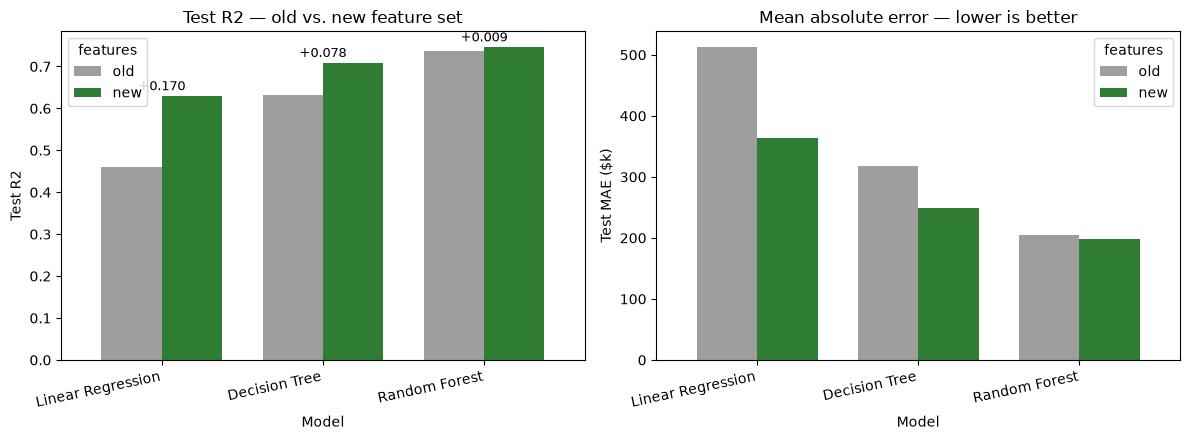

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

r2 = comparison["Test R2"][["old", "new"]]
r2.plot(kind="bar", ax=axes[0], color=["#9E9E9E", "#2E7D32"], width=0.75)
axes[0].set_ylabel("Test R2"); axes[0].set_title("Test R2 — old vs. new feature set")
axes[0].set_xticklabels(r2.index, rotation=12, ha="right"); axes[0].legend(title="features")
for i, (o, n) in enumerate(zip(r2["old"], r2["new"])):
    axes[0].annotate(f"+{n - o:.3f}", (i, max(o, n)), ha="center",
                     xytext=(0, 4), textcoords="offset points", fontsize=9)

mae = comparison["MAE"][["old", "new"]] / 1000
mae.plot(kind="bar", ax=axes[1], color=["#9E9E9E", "#2E7D32"], width=0.75)
axes[1].set_ylabel("Test MAE ($k)"); axes[1].set_title("Mean absolute error — lower is better")
axes[1].set_xticklabels(mae.index, rotation=12, ha="right"); axes[1].legend(title="features")

plt.tight_layout(); plt.show()

## 7. Which of the new features are doing the work?

Random Forest importances on the new feature set, with the newly added features highlighted.

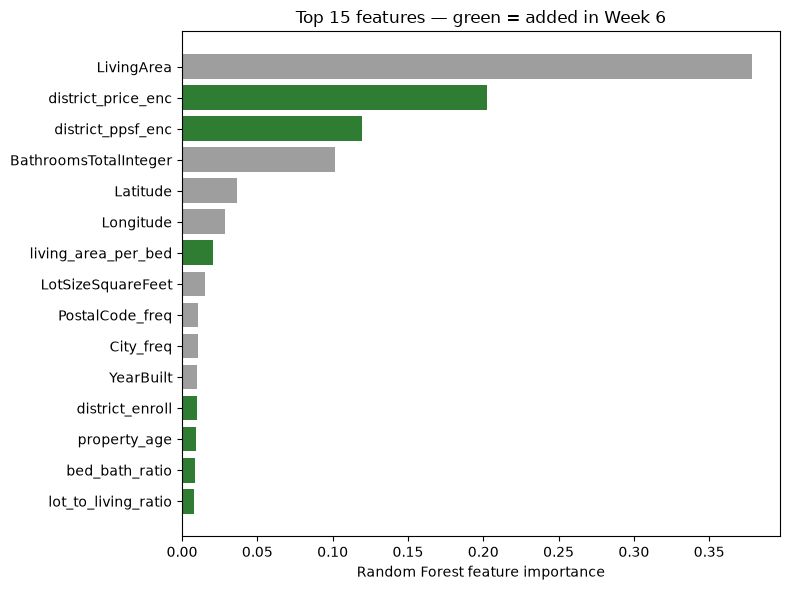

New features account for 40.1% of total RF importance

All Week 6 features, by importance:
district_price_enc         0.2025
district_ppsf_enc          0.1198
living_area_per_bed        0.0202
district_enroll            0.0100
property_age               0.0089
bed_bath_ratio             0.0089
lot_to_living_ratio        0.0082
total_rooms                0.0048
close_month_sin            0.0038
SchoolDistrict_freq        0.0036
close_month_cos            0.0032
district_sed_pct           0.0026
HighSchoolDistrict_freq    0.0026
district_el_pct            0.0008
has_garage                 0.0004
is_new_build               0.0002
is_unified                 0.0002
has_fireplace              0.0000


In [11]:
rf_new = fit_new["Random Forest"]
new_cols = set(ENGINEERED_NUMERIC + SCHOOL_NUMERIC + SCHOOL_ENCODED
               + ["SchoolDistrict_freq", "HighSchoolDistrict_freq"])

imp = (pd.Series(rf_new.feature_importances_, index=split_new["feature_cols"])
         .sort_values(ascending=False))
top = imp.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values,
        color=["#2E7D32" if c in new_cols else "#9E9E9E" for c in top.index])
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Top 15 features — green = added in Week 6")
plt.tight_layout(); plt.show()

share = imp[[c for c in imp.index if c in new_cols]].sum()
print(f"New features account for {share * 100:.1f}% of total RF importance\n")
print("All Week 6 features, by importance:")
print(imp[[c for c in imp.index if c in new_cols]].round(4).to_string())

## 8. Save the enriched dataset

`data/processed/sold_features.csv` is the input for Weeks 7-9. It stays **pre-split** and keeps the raw
district *names* so the encodings can be re-fit on whatever training window a later week chooses.

In [12]:
feature_cols_to_save = (["ClosePrice", "CloseDate", "year_month"] + BASE_NUMERIC + MISSING_FLAGS
                        + BASE_CATEGORICAL + ENGINEERED_NUMERIC
                        + ["SchoolDistrict", "HighSchoolDistrict", "district_type"] + SCHOOL_NUMERIC)
feature_cols_to_save = [c for c in dict.fromkeys(feature_cols_to_save) if c in d.columns]

out_path = "data/processed/sold_features.csv"
d[feature_cols_to_save].to_csv(out_path, index=False)
print(f"Saved {len(d):,} rows x {len(feature_cols_to_save)} cols -> {out_path}")

comparison.round(4).to_csv("data/processed/feature_set_comparison.csv")
print("Saved -> data/processed/feature_set_comparison.csv")

print(f"\n=== WEEK 6 FEATURE ENGINEERING (test month {split_new['test_month']}, X={BEST_X}) ===")
for model in comparison.index:
    r = comparison.loc[model]
    print(f"{model:20s}  R2 {r[('Test R2', 'old')]:.4f} -> {r[('Test R2', 'new')]:.4f} "
          f"({r[('Test R2', 'gain')]:+.4f})   MAE ${r[('MAE', 'old')]:,.0f} -> ${r[('MAE', 'new')]:,.0f}")
best_model = comparison[("Test R2", "new")].idxmax()
print(f"\nBest with new features: {best_model} "
      f"(test R2 = {comparison.loc[best_model, ('Test R2', 'new')]:.4f})")

Saved 319,311 rows x 36 cols -> data/processed/sold_features.csv
Saved -> data/processed/feature_set_comparison.csv

=== WEEK 6 FEATURE ENGINEERING (test month 2026-05, X=13) ===
Linear Regression     R2 0.4602 -> 0.6301 (+0.1699)   MAE $512,873 -> $363,988
Decision Tree         R2 0.6316 -> 0.7094 (+0.0778)   MAE $317,811 -> $248,325
Random Forest         R2 0.7378 -> 0.7465 (+0.0087)   MAE $205,264 -> $198,313

Best with new features: Random Forest (test R2 = 0.7465)
